<a href="https://colab.research.google.com/github/Jadyli929/Jadyli929.github.io/blob/gh-pages/hw4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Create the opioid sqlite database from https://smart-stats.github.io/ds4bio_book/book/_build/html/sqlite.html. However, only go to the step where the csv files are read into the database. Then exit sqlite and you should have a file opioid.db that has the data. Next, read the three tables into pandas dataframes and do the remaining data wrangling from the sqlite chapter directly in pandas. Add the python code to your hw4.ipynb file.

In [35]:
import sqlite3 as sq3
import matplotlib.pyplot as plt

In [45]:
!rm -f county_pop_arcos.csv land_area.csv county_annual.csv
!wget https://raw.githubusercontent.com/opencasestudies/ocs-bp-opioid-rural-urban/master/data/simpler_import/county_pop_arcos.csv
!wget https://raw.githubusercontent.com/opencasestudies/ocs-bp-opioid-rural-urban/master/data/simpler_import/land_area.csv
!wget https://raw.githubusercontent.com/opencasestudies/ocs-bp-opioid-rural-urban/master/data/simpler_import/county_annual.csv


--2025-02-18 16:13:46--  https://raw.githubusercontent.com/opencasestudies/ocs-bp-opioid-rural-urban/master/data/simpler_import/county_pop_arcos.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2771268 (2.6M) [text/plain]
Saving to: ‘county_pop_arcos.csv’

county_pop_arcos.cs 100%[===================>]   2.64M  --.-KB/s    in 0.03s   

2025-02-18 16:13:47 (86.7 MB/s) - ‘county_pop_arcos.csv’ saved [2771268/2771268]

--2025-02-18 16:13:47--  https://raw.githubusercontent.com/opencasestudies/ocs-bp-opioid-rural-urban/master/data/simpler_import/land_area.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.1

In [47]:
%sql sqlite:///opioid.db

In [48]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine("sqlite:///opioid.db")

pd.read_csv("county_pop_arcos.csv").to_sql("population", con=engine, if_exists="replace", index=False)
pd.read_csv("county_annual.csv").to_sql("annual", con=engine, if_exists="replace", index=False)
pd.read_csv("land_area.csv").to_sql("land", con=engine, if_exists="replace", index=False)

3198

In [49]:
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

In [50]:
%%sql
SELECT name FROM sqlite_master WHERE type='table';

   sqlite:///opiod.db
 * sqlite:///opioid.db
Done.


name


In [51]:
con = sq3.connect('opioid.db')
# cursor() creates an object that can execute functions in the sqlite cursor

sql = con.cursor()

# you have to close the connection
con.close

<function Connection.close()>

In [52]:
# Load the tables into pandas dataframes
population_df = pd.read_sql_query("SELECT * FROM population", con)
annual_df = pd.read_sql_query("SELECT * FROM annual", con)
land_df = pd.read_sql_query("SELECT * FROM land", con)

# Close the connection
con.close()

# Display the first few rows of each dataframe
print(population_df.head())
print(annual_df.head())
print(land_df.head())

   Unnamed: 0 BUYER_COUNTY BUYER_STATE  countyfips  STATE  COUNTY county_name  \
0           1      AUTAUGA          AL        1001      1       1     Autauga   
1           2      BALDWIN          AL        1003      1       3     Baldwin   
2           3      BARBOUR          AL        1005      1       5     Barbour   
3           4         BIBB          AL        1007      1       7        Bibb   
4           5       BLOUNT          AL        1009      1       9      Blount   

                      NAME    variable  year  population  
0  Autauga County, Alabama  B01003_001  2006       51328  
1  Baldwin County, Alabama  B01003_001  2006      168121  
2  Barbour County, Alabama  B01003_001  2006       27861  
3     Bibb County, Alabama  B01003_001  2006       22099  
4   Blount County, Alabama  B01003_001  2006       55485  
   Unnamed: 0 BUYER_COUNTY BUYER_STATE  year  count  DOSAGE_UNIT  countyfips
0           1    ABBEVILLE          SC  2006    877     363620.0     45001.0
1    

In [53]:
# 1. Delete rows from annual where BUYER_COUNTY = "NA"
annual_df = annual_df[annual_df['BUYER_COUNTY'] != 'NA']

# 2. Create land_area dataframe by selecting columns from land_df
land_area_df = land_df[['Areaname', 'STCOU', 'LND110210D']]

# 3. Rename column 'STCOU' to 'countyfips'
land_area_df.rename(columns={'STCOU': 'countyfips'}, inplace=True)

# 4. Create county_info dataframe by joining population_df and land_area_df on countyfips
county_info_df = pd.merge(population_df, land_area_df, on='countyfips', how='left')

print(county_info_df.head())

   Unnamed: 0 BUYER_COUNTY BUYER_STATE  countyfips  STATE  COUNTY county_name  \
0           1      AUTAUGA          AL        1001      1       1     Autauga   
1           2      BALDWIN          AL        1003      1       3     Baldwin   
2           3      BARBOUR          AL        1005      1       5     Barbour   
3           4         BIBB          AL        1007      1       7        Bibb   
4           5       BLOUNT          AL        1009      1       9      Blount   

                      NAME    variable  year  population     Areaname  \
0  Autauga County, Alabama  B01003_001  2006       51328  Autauga, AL   
1  Baldwin County, Alabama  B01003_001  2006      168121  Baldwin, AL   
2  Barbour County, Alabama  B01003_001  2006       27861  Barbour, AL   
3     Bibb County, Alabama  B01003_001  2006       22099     Bibb, AL   
4   Blount County, Alabama  B01003_001  2006       55485   Blount, AL   

   LND110210D  
0      594.44  
1     1589.78  
2      884.88  
3      622

<ipython-input-53-4e7c1541b95b>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  land_area_df.rename(columns={'STCOU': 'countyfips'}, inplace=True)


2. Create a scatterplot of the average number of opiod pills by year by loading the sql database in python. See the example here. Don't do the intervals (little vertical lines), only the points.

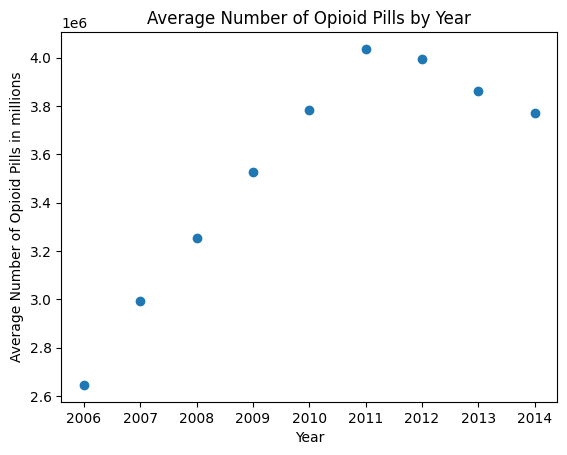

In [54]:
import matplotlib.pyplot as plt

# Connect to the SQL database
con = sq3.connect('opioid.db')

# Query to get the average number of opioid pills by year
query = """
SELECT year, AVG(DOSAGE_UNIT) as avg_opiod_pills
FROM annual
GROUP BY year
"""

# Load the data into a pandas DataFrame
df = pd.read_sql_query(query, con)

# Close the database connection
con.close()

# Create a scatterplot
plt.scatter(df['year'], df['avg_opiod_pills'])
plt.xlabel('Year')
plt.ylabel('Average Number of Opioid Pills in millions')
plt.title('Average Number of Opioid Pills by Year')
plt.show()


3. Repeat the steps of loading and merging the opiod data files in R. That is, follow the steps of loading and merging the three csv files as well as the data cleaning described in the notes in R.

4. Take your R code from the previous step and call it from python instead of R. Convert the resulting dataset to a pandas dataframe.

You should have an ipython notebook as well as an R file.

In [55]:
import rpy2
import rpy2.rinterface as ri
import rpy2.robjects as ro
from rpy2.robjects.packages import importr

In [66]:
ro.r('''
population <- read.csv("https://raw.githubusercontent.com/opencasestudies/ocs-bp-opioid-rural-urban/master/data/simpler_import/county_pop_arcos.csv")
land <- read.csv("https://raw.githubusercontent.com/opencasestudies/ocs-bp-opioid-rural-urban/master/data/simpler_import/land_area.csv")
annual <- read.csv("https://raw.githubusercontent.com/opencasestudies/ocs-bp-opioid-rural-urban/master/data/simpler_import/county_annual.csv")
''')

X,BUYER_COUNTY,BUYER_STATE,year,count,DOSAGE_UNIT,countyfips
...,...,...,...,...,...,...


In [67]:
ro.r('''
library(dplyr)

annual <- annual[annual$BUYER_COUNTY != "NA", ]

land <- land |>
  select(Areaname, STCOU, LND110210D) |>
  rename(countyfips = STCOU) #new name = old name

county_info <- left_join(population, land, by = "countyfips")

county_info
''')

X,BUYER_COUNTY,BUYER_STATE,...,population,Areaname,LND110210D
1,'AUTAUGA','AL',...,"51,328","'Autauga,...",594.440000
2,'BALDWIN','AL',,"168,121","'Baldwin,...",1589.780000
3,'BARBOUR','AL',,"27,861","'Barbour,...",884.880000
4,'BIBB','AL',,"22,099","'Bibb, AL'",622.580000
...,...,...,,...,...,...
"28,262",'WESTON','WY',,"7,135","'Weston, ...",2398.090000
"28,263",'SKAGWAY','AK',,996,"'Skagway,...",452.330000
"28,264",'HOONAH A...,'AK',,"2,126",'Hoonah-A...,7524.920000
"28,265",'PETERSBU...,'AK',,"3,212",'Petersbu...,3281.980000
